# OYICD: operating modes and short process cycles

Explore eight process signals in 519 short recordings spanning twelve relative
months. Filename modes identify entire recordings, not annotated phases within
an operating cycle. Each capture has 2,048 samples at approximately 4 ms spacing.

[Provider and attribution](https://www.kaggle.com/datasets/inIT-OWL/one-year-industrial-component-degradation)
· [Dataset guide](../../pdmdata/datasets/oyicd/README.md)

Run `pdmdata.download("oyicd")` explicitly if needed. This notebook reads local
data only. The source ZIP contains two byte-identical copies of each recording;
the loader verifies agreement and counts each unique filename once.


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pdmdata").is_dir())
sys.path.insert(0, str(ROOT))
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display
import pdmdata
from pdmdata.datasets.oyicd import inventory
from pdmdata.datasets.oyicd.loader import SENSOR_COLUMNS
from pdmdata.datasets.oyicd.viz import SIGNAL_LABELS, plot_waveforms, plot_coverage, plot_modes

files = inventory()
print(f"Unique recordings: {files.height}; observations: {files['samples'].sum():,}")
print(f"Local CSV copies: {files['copies'].sum()}; modes: {sorted(files['mode'].unique().to_list())}")
display(files.select("filename", "month", "mode", "samples", "copies", "span_s").head(12))
print(f"Sample spacing range: {files['min_step_s'].min():.8f} to {files['max_step_s'].max():.8f} seconds")


Unique recordings: 519; observations: 1,062,912
Local CSV copies: 1038; modes: [1, 2, 3, 4, 5, 6, 7, 8]


filename,month,mode,samples,copies,span_s
str,i64,i64,i64,i64,f64
"""01-04T184148_000_mode1.csv""",1,1,2048,2,8.187999
"""01-04T184424_001_mode1.csv""",1,1,2048,2,8.187999
"""01-04T184835_002_mode1.csv""",1,1,2048,2,8.187999
"""01-04T185047_003_mode1.csv""",1,1,2048,2,8.187999
"""01-04T185257_004_mode1.csv""",1,1,2048,2,8.187999
…,…,…,…,…,…
"""01-05T133550_007_mode1.csv""",1,1,2048,2,8.187999
"""01-05T140727_008_mode1.csv""",1,1,2048,2,8.187999
"""01-05T140919_009_mode1.csv""",1,1,2048,2,8.187999


Sample spacing range: 0.00399999 to 0.00400000 seconds


## Recording coverage

Relative months are numbered 1–12; they are not calendar months. Mode coverage
is uneven, so comparing early and late recordings without controlling for mode
can mix operating differences with changes over the year.


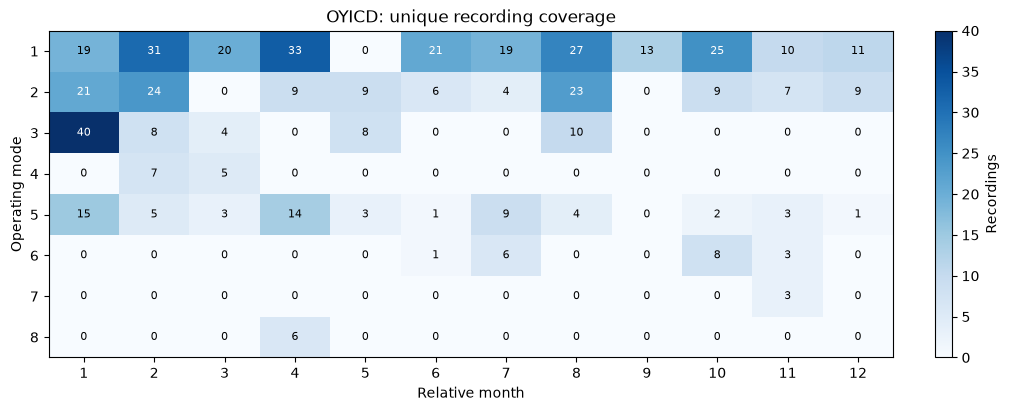

In [2]:
coverage = plot_coverage(files)
plt.show()


## Select one recording

Change MONTH and MODE, then choose a filename from the matching rows. The default
uses the lexicographically first recording in month 1, mode 1. Selection does not
assume that it represents a healthy blade. Mode names are retained as numeric
IDs; no unverified mapping to machine actions is supplied.


In [3]:
MONTH, MODE = 1, 1
candidates = files.filter((pl.col("month") == MONTH) & (pl.col("mode") == MODE)).sort("filename")
if candidates.is_empty():
    raise ValueError("No recordings match this month/mode; consult the coverage plot")
RECORDING = candidates["filename"][0]
frame = pdmdata.load("oyicd", recording=RECORDING)
print("Selected:", RECORDING)
display(pl.DataFrame({"column": SENSOR_COLUMNS, "plot_label": SIGNAL_LABELS,
    "unique_values": [frame[c].n_unique() for c in SENSOR_COLUMNS],
    "standard_deviation": [frame[c].std() for c in SENSOR_COLUMNS]}))


Selected: 01-04T184148_000_mode1.csv


column,plot_label,unique_values,standard_deviation
str,str,i64,f64
"""pCut::Motor_Torque""","""Cut motor torque""",2048,0.48638
"""pCut::CTRL_Position_controller…","""Cut position lag error""",2028,0.093027
"""pCut::CTRL_Position_controller…","""Cut actual position""",1840,3781.230093
"""pCut::CTRL_Position_controller…","""Cut actual speed""",1565,3486.16446
"""pSvolFilm::CTRL_Position_contr…","""Film actual position""",2048,7973.94829
"""pSvolFilm::CTRL_Position_contr…","""Film actual speed""",772,1073.54924
"""pSvolFilm::CTRL_Position_contr…","""Film position lag error""",2048,0.10976
"""pSpintor::VAX_speed""","""Spintor VAX speed""",32,73.928099


## Eight-signal waveform overview

All values retain their source scale, including the large accumulated positions.
The horizontal axis subtracts only the first timestamp. No resampling, smoothing,
or concatenation is performed. Signals may cycle within a recording, but cycle
phase boundaries are not labeled.


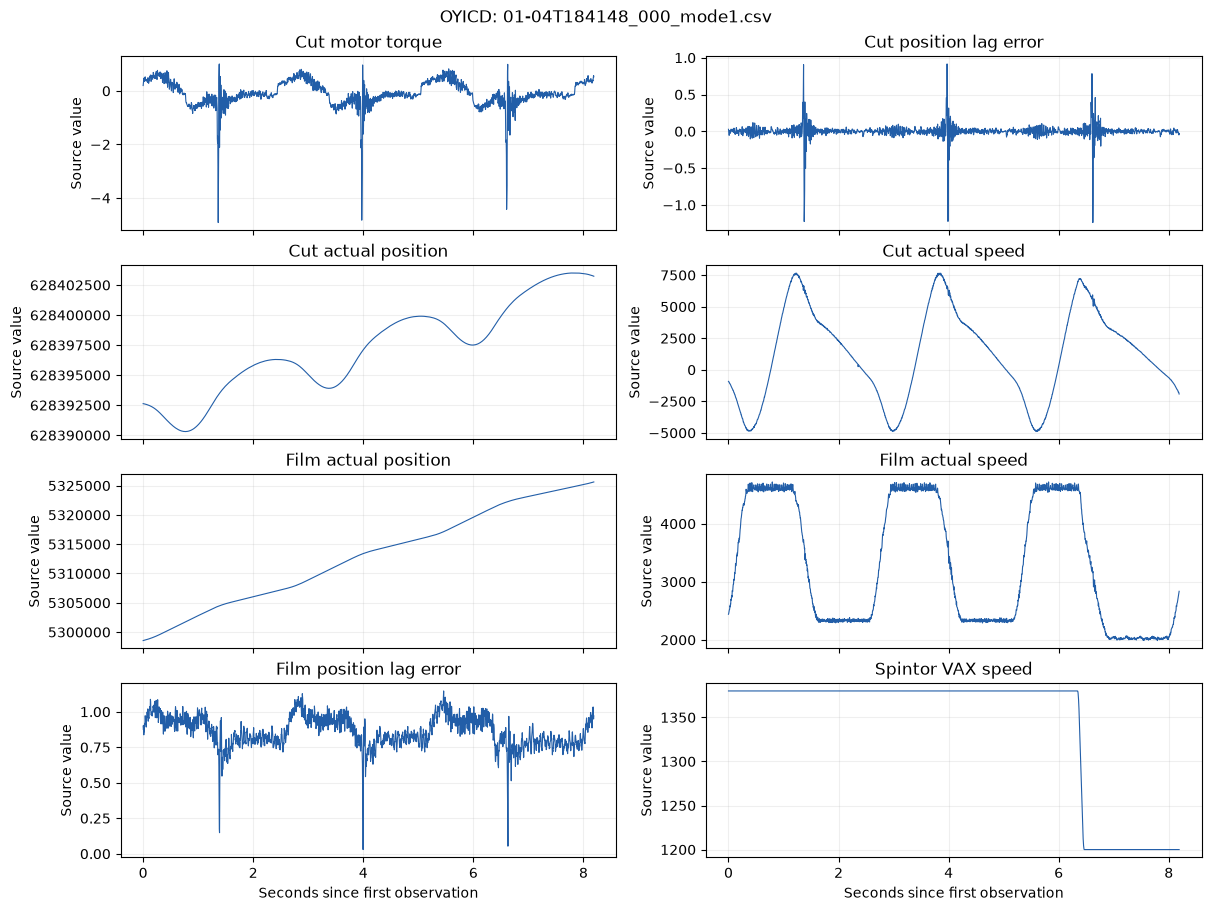

In [4]:
overview = plot_waveforms(frame)
assets = ROOT / "pdmdata/datasets/oyicd/assets"
assets.mkdir(parents=True, exist_ok=True)
overview.savefig(assets / "waveforms.png", dpi=100)
plt.show()


## Zoom into the first second

The default 250 samples expose faster changes in the same recording. Adjust
START and STOP as sample indices while keeping the observed time axis.


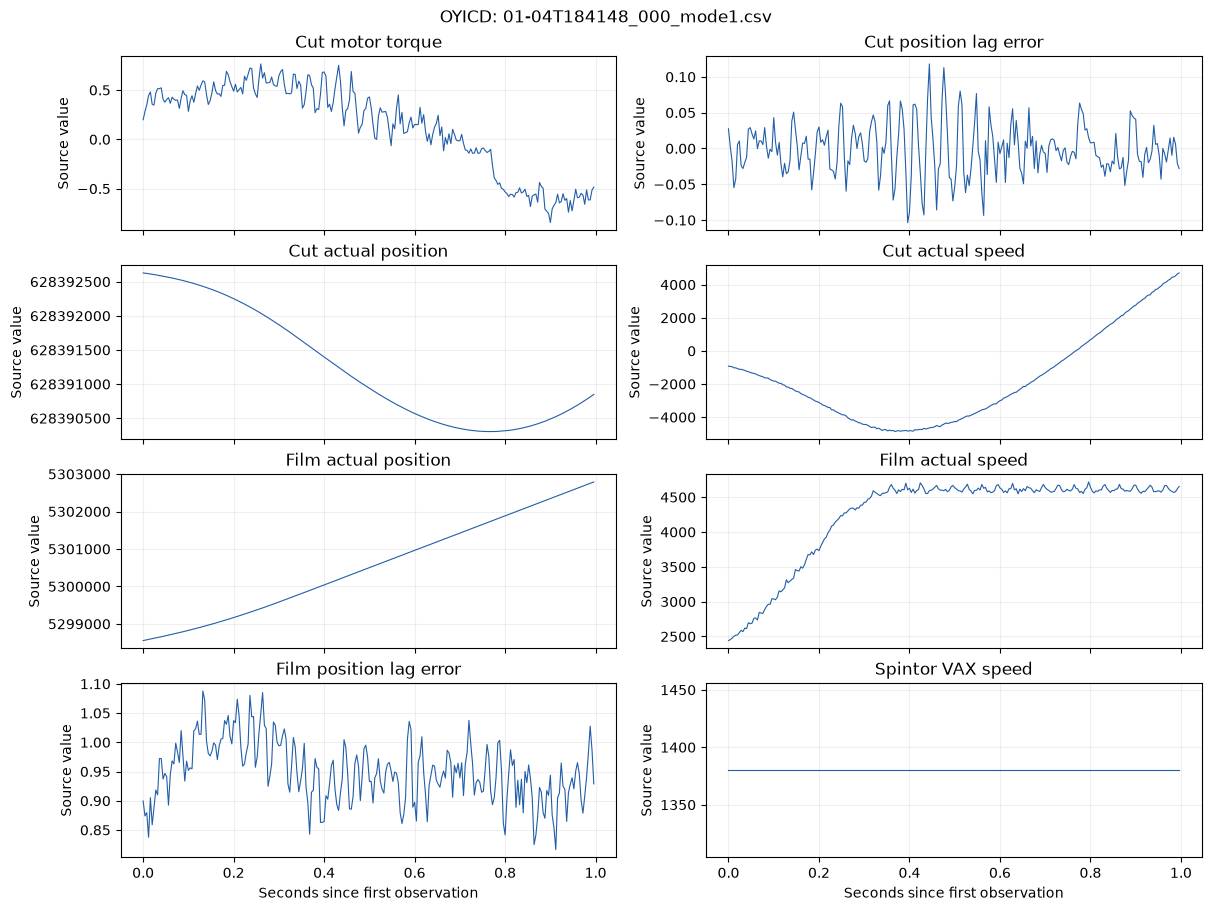

In [5]:
START, STOP = 0, 250
zoom = plot_waveforms(frame, start=START, stop=STOP)
plt.show()


## One torque example per mode

Each panel uses the first available filename for that mode and shared amplitude
limits. These are independent captures, often from different relative months.
They are examples, not average mode profiles or evidence of an observed transition
from one mode to another. The selected filenames make the comparison reproducible.


mode,month,filename
i64,i64,str
1,1,"""01-04T184148_000_mode1.csv"""
2,1,"""01-06T153013_019_mode2.csv"""
3,1,"""01-22T113142_055_mode3.csv"""
4,2,"""02-28T141222_152_mode4.csv"""
5,1,"""01-12T111903_040_mode5.csv"""
6,6,"""06-28T140506_307_mode6.csv"""
7,11,"""11-20T155357_488_mode7.csv"""
8,4,"""04-05T084050_202_mode8.csv"""


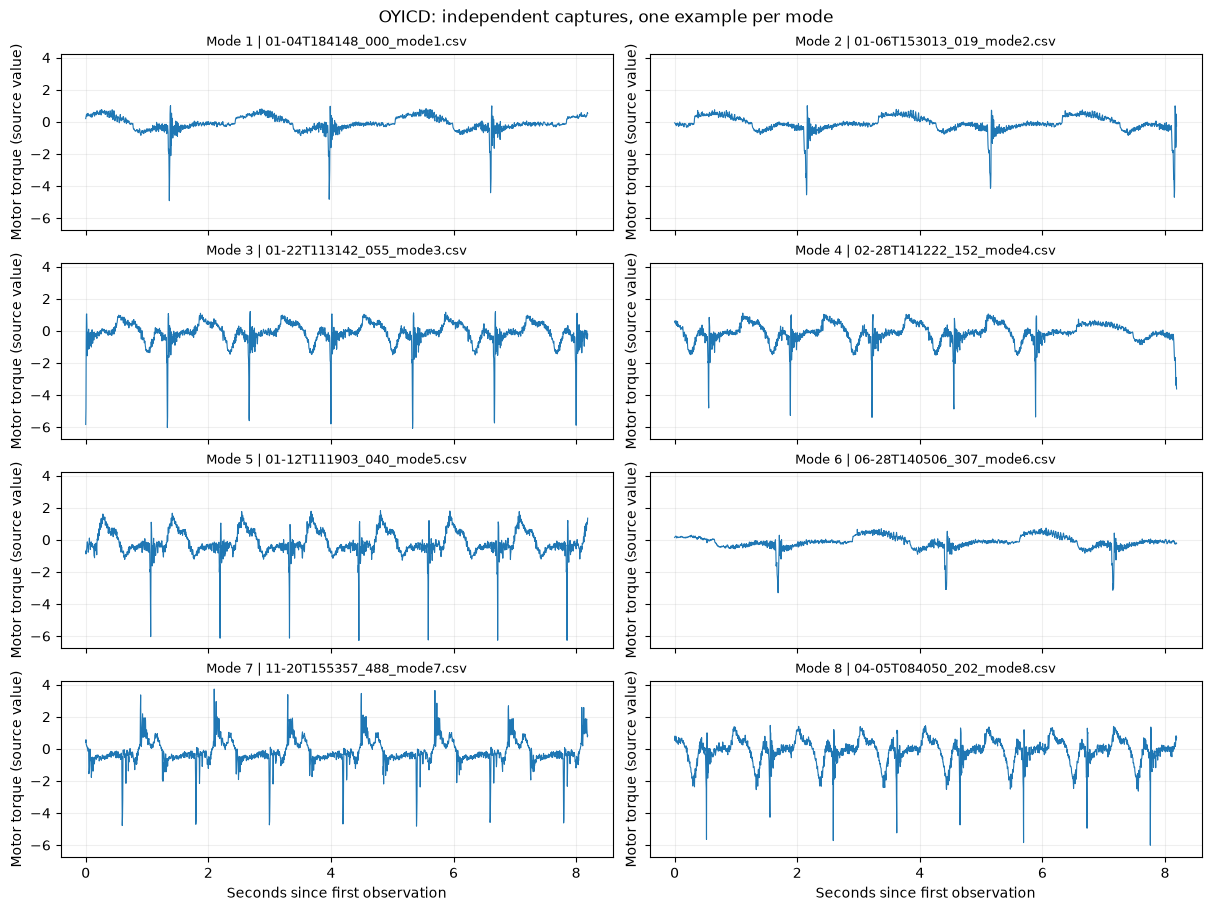

In [6]:
selected = files.sort("filename").group_by("mode", maintain_order=True).first().sort("mode")
display(selected.select("mode", "month", "filename"))
examples = [pdmdata.load("oyicd", recording=name) for name in selected["filename"]]
mode_examples = plot_modes(examples)
plt.show()


## Implications for dependency-based segmentation

- Use the eight process signals as candidates and keep filename, month, and mode
  outside the sensor inputs. Inspect constants, trends, and channel scales first.
- The 4 ms sampling provides short-term detail, while sparse captures across
  twelve months provide a separate, much slower observation scale. The data are
  not a continuous year-long signal.
- Distinguish repeated within-capture motion from changes between filename modes.
  A constant mode label does not annotate the phases of the motion cycle.
- Accumulated position channels can have large offsets and trends; decide and
  document appropriate detrending or differencing using training data only.
- Compare dependency changes against mean/variance changes. These exploratory
  waveforms alone do not establish a multi-scale dependency model's advantage.
- Avoid splitting overlapping windows of the same capture across train/test sets.
  Also exclude duplicate source copies from evaluation.
- Blade wear, replacement times, failure events, and RUL are not explicit targets.
  Relative month should not be equated with blade age or wear severity.

Source: inIT-OWL, *One Year Industrial Component Degradation*, associated with
von Birgelen et al. (2018), *Self-Organizing Maps for Anomaly Localization and
Predictive Maintenance in Cyber-Physical Production Systems*.
Data and the derived preview are attributed under
[CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/).
